In [1]:
import pandas as pd
import glob
import os

folder_path = 'CAISO_data'

all_files = glob.glob(os.path.join(folder_path, "*.xlsx"))

df_list = []

for file in all_files:

    # usecols="A,B,G" reads only columns A (Date), B (HR), and G (Caiso)
    temp_df = pd.read_excel(file, usecols="A,B,G")
    
    temp_df.columns = ['Date', 'Hour', 'CAISO Load (MW)']
    
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

# Add Timestamp + set as index
# And drop problem last two rows where 'Hour' or 'Date' are read wrong
df = df.dropna(subset=['Hour', 'Date'])

df['Date'] = pd.to_datetime(df['Date'])
df['Timestamp'] = df['Date'] + pd.to_timedelta(df['Hour'].astype(int) - 1, unit='h')

df.set_index('Timestamp', inplace=True)
df.sort_index(inplace=True)

print(f"Successfully loaded {len(all_files)} files.")
df.columns

Successfully loaded 27 files.


Index(['Date', 'Hour', 'CAISO Load (MW)'], dtype='str')

In [2]:
march_data = df[df.index.month == 3]
march_data['Day'] = march_data.index.day_name()
march_data['Day_Numeric'] = march_data.index.day

march_data.columns

Index(['Date', 'Hour', 'CAISO Load (MW)', 'Day', 'Day_Numeric'], dtype='str')

In [6]:
peak_indices = march_data.groupby(march_data.index.year)['CAISO Load (MW)'].idxmax()
march_peak = march_data.loc[peak_indices].copy()

march_peak

,Date,Hour,CAISO Load (MW),Day,Day_Numeric
Timestamp,,,,,
2019-03-06 18:00:00,2019-03-06,19.0,28185.997457,Wednesday,6
2020-03-05 18:00:00,2020-03-05,19.0,28213.764162,Thursday,5
2021-03-10 18:00:00,2021-03-10,19.0,28135.800000,Wednesday,10
2022-03-23 19:00:00,2022-03-23,20.0,28687.820000,Wednesday,23
2023-03-01 19:00:00,2023-03-01,20.0,28696.964726,Wednesday,1
2024-03-06 18:00:00,2024-03-06,19.0,26952.900643,Wednesday,6
2025-03-14 10:00:00,2025-03-14,11.0,28127.034768,Friday,14


In [7]:
march_peak['Year'] = march_peak.index.year
march_peak_filtered = march_peak[march_peak['Year'] != 2024].copy()

march_peak_filtered

,Date,Hour,CAISO Load (MW),Day,Day_Numeric,Year
Timestamp,,,,,,
2019-03-06 18:00:00,2019-03-06,19.0,28185.997457,Wednesday,6,2019
2020-03-05 18:00:00,2020-03-05,19.0,28213.764162,Thursday,5,2020
2021-03-10 18:00:00,2021-03-10,19.0,28135.800000,Wednesday,10,2021
2022-03-23 19:00:00,2022-03-23,20.0,28687.820000,Wednesday,23,2022
2023-03-01 19:00:00,2023-03-01,20.0,28696.964726,Wednesday,1,2023
2025-03-14 10:00:00,2025-03-14,11.0,28127.034768,Friday,14,2025


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Filter out the March 2024 peak from the trend due to its unnatural behavior.
march_peak['Year'] = march_peak.index.year
march_peak_filtered = march_peak[march_peak['Year'] != 2024].copy()

# Compute Trend
# Train on the 6 non-outlier years
X_train = march_peak_filtered[['Year']].values
y_train = march_peak_filtered['CAISO Load (MW)'].values

model = LinearRegression()
model.fit(X_train, y_train)

march_peak['Trend'] = model.predict(march_peak[['Year']].values)

# Compute Residuals
# We can subtract Trend from Actual for all 7 years
march_peak['Residual'] = march_peak['CAISO Load (MW)'] - march_peak['Trend']

# Calculate Median Residual excluding 2024
median_res = march_peak.loc[march_peak['Year'] != 2024, 'Residual'].median()

march_peak

,Date,Hour,CAISO Load (MW),Day,Day_Numeric,Year,Trend,Residual
Timestamp,,,,,,,,
2019-03-06 18:00:00,2019-03-06,19.0,28185.997457,Wednesday,6,2019,28268.177762,-82.180305
2020-03-05 18:00:00,2020-03-05,19.0,28213.764162,Thursday,5,2020,28295.572421,-81.808259
2021-03-10 18:00:00,2021-03-10,19.0,28135.800000,Wednesday,10,2021,28322.967080,-187.167080
2022-03-23 19:00:00,2022-03-23,20.0,28687.820000,Wednesday,23,2022,28350.361739,337.458261
2023-03-01 19:00:00,2023-03-01,20.0,28696.964726,Wednesday,1,2023,28377.756397,319.208329
2024-03-06 18:00:00,2024-03-06,19.0,26952.900643,Wednesday,6,2024,28405.151056,-1452.250413
2025-03-14 10:00:00,2025-03-14,11.0,28127.034768,Friday,14,2025,28432.545715,-305.510947


In [ ]:
# Backtest for 2023, 2024, and 2025
print("--- Backtest Analysis (2023-2025) ---")
backtest_errors_pct = []

for bt_year in [2023, 2024, 2025]:
    # Training data: All available years BEFORE the backtest year, excluding 2024
    hist_mask = (march_peak['Year'] < bt_year) & (march_peak['Year'] != 2024)
    hist_df = march_peak[hist_mask]
    
    if len(hist_df) >= 2:
        # 1. Fit trend on historical data
        bt_model = LinearRegression().fit(hist_df[['Year']].values, hist_df['CAISO Load (MW)'].values)
        
        # 2. Forecast = Trend(bt_year) + Median of historical residuals
        bt_trend = bt_model.predict([[bt_year]])[0]
        bt_median_res = hist_df['Residual'].median()
        forecast = bt_trend + bt_median_res
        
        # 3. Calculate Error Metrics
        actual = march_peak.loc[march_peak['Year'] == bt_year, 'CAISO Load (MW)'].values[0]
        abs_error = abs(actual - forecast)
        pct_error = (abs_error / actual) * 100
        backtest_errors_pct.append(pct_error)
        
        note = " (Outlier Year)" if bt_year == 2024 else ""
        print(f"Year {bt_year}{note}:")
        print(f"  Forecast: {forecast:.1f} MW | Actual: {actual:.1f} MW")
        print(f"  Abs Error: {abs_error:.1f} MW | Pct Error: {pct_error:.2f}%")
        print("-" * 40)

# Calculate Mean Absolute Percentage Error (MAPE)
mape = np.mean(backtest_errors_pct)
print(f"Backtest MAPE: {mape:.2f}%")

--- Backtest Analysis (2023-2025) ---
Year 2023:
  Forecast: 28580.7 MW | Actual: 28697.0 MW
  Abs Error: 116.2 MW | Pct Error: 0.41%
----------------------------------------
Year 2024 (Outlier Year):
  Forecast: 28751.1 MW | Actual: 26952.9 MW
  Abs Error: 1798.2 MW | Pct Error: 6.67%
----------------------------------------
Year 2025:
  Forecast: 28900.7 MW | Actual: 28127.0 MW
  Abs Error: 773.6 MW | Pct Error: 2.75%
----------------------------------------
Backtest MAPE: 3.28%


In [ ]:
# 2026 forecast
trend_2026 = model.predict([[2026]])[0]
forecast_2026 = trend_2026 + median_res

print("\n--- Final Results ---")
print(f"Structural Trend for 2026: {trend_2026:.2f} MW")
print(f"Median Residual (excl. 2024): {median_res:.2f} MW")
print(f"Final March 2026 Forecast: {forecast_2026:.2f} MW")


--- Final Results ---
Structural Trend for 2026: 28459.94 MW
Median Residual (excl. 2024): -81.99 MW
Final March 2026 Forecast: 28377.95 MW


<Figure size 640x480 with 0 Axes>

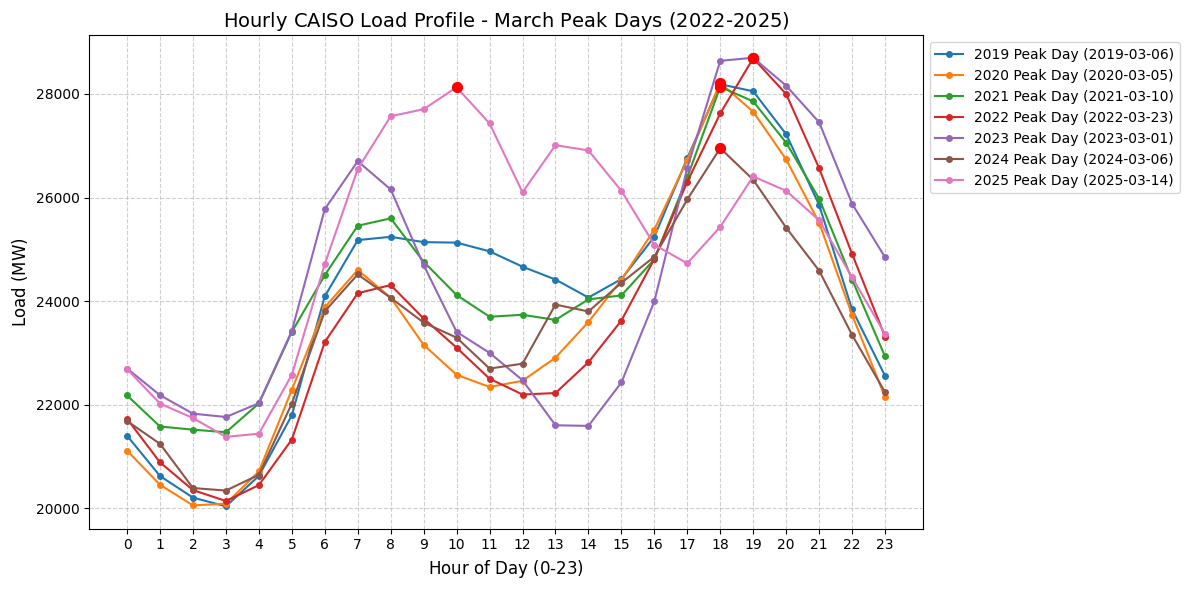

In [ ]:
import matplotlib.pyplot as plt

# Years we want to compare
years_to_plot = [2019, 2020, 2021, 2022, 2023, 2024, 2025]

# Initialize the plot
plt.clf()
plt.figure(figsize=(12, 6))

for year in years_to_plot:
    if year in peak_indices.index:
        # 1. Get the specific timestamp of the peak
        peak_ts = peak_indices.loc[year]
        peak_date = peak_ts.date()
        
        # 2. Filter march_data for the entire day of that peak
        # We use .index.date to match the specific calendar day
        day_data = march_data[march_data.index.date == peak_date].copy()
        day_data = day_data.sort_index()
        
        # 3. Extract the hour (0-23) and the load
        # Since your timestamp was created as (Hour - 1), 0 is 12 AM and 23 is 11 PM
        x_hours = day_data.index.hour
        y_load = day_data['CAISO Load (MW)']
        
        # 4. Plot the line for this year
        plt.plot(x_hours, y_load, marker='o', markersize=4, label=f"{year} Peak Day ({peak_date})")
        
        # Optional: Annotate the specific peak point
        plt.scatter(peak_ts.hour, march_peak.loc[peak_ts, 'CAISO Load (MW)'], 
                    color='red', zorder=5, s=50)

# Formatting the chart
plt.title(r"$\text{Hourly CAISO Load Profile - March Peak Days (2022-2025)}$", fontsize=14)
plt.xlabel(r"$\text{Hour of Day (0-23)}$", fontsize=12)
plt.ylabel(r"$\text{Load (MW)}$", fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

# Save the plot
# plt.savefig('peak_day_hourly_load.png')

In [29]:
# Question 3c)

all_shape_factors = []
years_to_process = peak_indices.index.unique()

for year in years_to_process:
    # Identify the specific peak day for this year
    peak_ts = peak_indices.loc[year]
    peak_val = march_data.loc[peak_ts, 'CAISO Load (MW)']
    
    # Isolate the 24-hour window for that day
    day_data = march_data[march_data.index.date == peak_ts.date()].sort_index()
    
    # Calculate s_h = L_h / L_peak
    # Ensuring we only take exactly 24 observations
    if len(day_data) == 24:
        s_h = day_data['CAISO Load (MW)'].values / peak_val
        all_shape_factors.append(s_h)

# Convert to DataFrame: Rows = Years, Columns = Hours (0-23)
shape_matrix = pd.DataFrame(all_shape_factors)

# Compute "Typical" Shape Factors (Median)
typical_shape = shape_matrix.median(axis=0)

# Consistency Check (Ensure max value = 1)
# This adjusts for slight shifts in peak timing across years
typical_shape = typical_shape / typical_shape.max()

# Apply to 2026 Forecast (L*)s
L_star = forecast_2026 
forecast_2026_hourly = typical_shape * L_star

# Print output
forecast_output = pd.DataFrame({
    'Hour': range(24),
    'Typical_Shape_Factor': typical_shape.values,
    'Forecast_2026_MW': forecast_2026_hourly.values
})

print(f"\n--- 2026 Hourly Forecast based on L* = {L_star:.2f} MW ---")
print(forecast_output.to_string(index=False))


--- 2026 Hourly Forecast based on L* = 28377.95 MW ---
 Hour  Typical_Shape_Factor  Forecast_2026_MW
    0              0.788397      22373.077164
    1              0.767048      21767.237597
    2              0.756660      21472.451625
    3              0.754867      21421.571958
    4              0.762368      21634.446555
    5              0.802697      22778.894919
    6              0.870877      24713.709539
    7              0.904736      25674.558363
    8              0.895568      25414.370965
    9              0.875119      24834.092733
   10              0.857220      24326.132383
   11              0.842190      23899.626275
   12              0.843675      23941.762595
   13              0.840137      23841.376006
   14              0.853977      24234.113537
   15              0.865225      24553.316929
   16              0.891970      25312.282809
   17              0.937989      26618.190277
   18              1.000000      28377.946092
   19              0.990

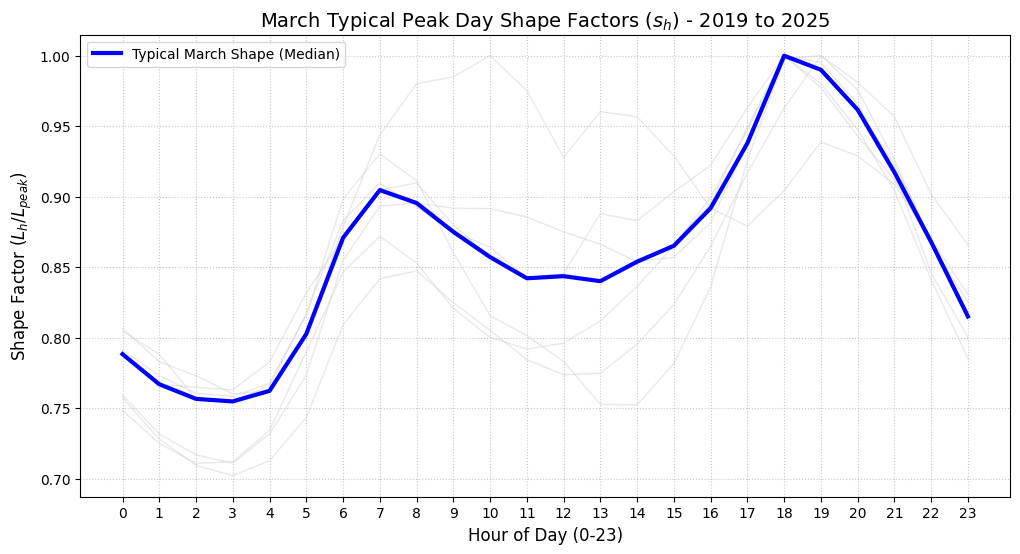

In [31]:
plt.figure(figsize=(12, 6))

# Plot individual years in light gray
for i in range(len(shape_matrix)):
    plt.plot(range(24), shape_matrix.iloc[i], color='lightgray', alpha=0.5, linewidth=1)

# Plot the shape curve
plt.plot(range(24), typical_shape, color='blue', linewidth=3, label='Typical March Shape (Median)')

plt.title('March Typical Peak Day Shape Factors ($s_h$) - 2019 to 2025', fontsize=14)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Shape Factor ($L_h / L_{peak}$)', fontsize=12)
plt.xticks(range(24))
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()